<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 181.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 177.8 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 149.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 165.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 160.2 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-04-17 08:54:28--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  25.2MB/s    in 5.0s    

2026-04-17 08:54:33 (30.7 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



Note: you may need to restart the kernel to use updated packages.


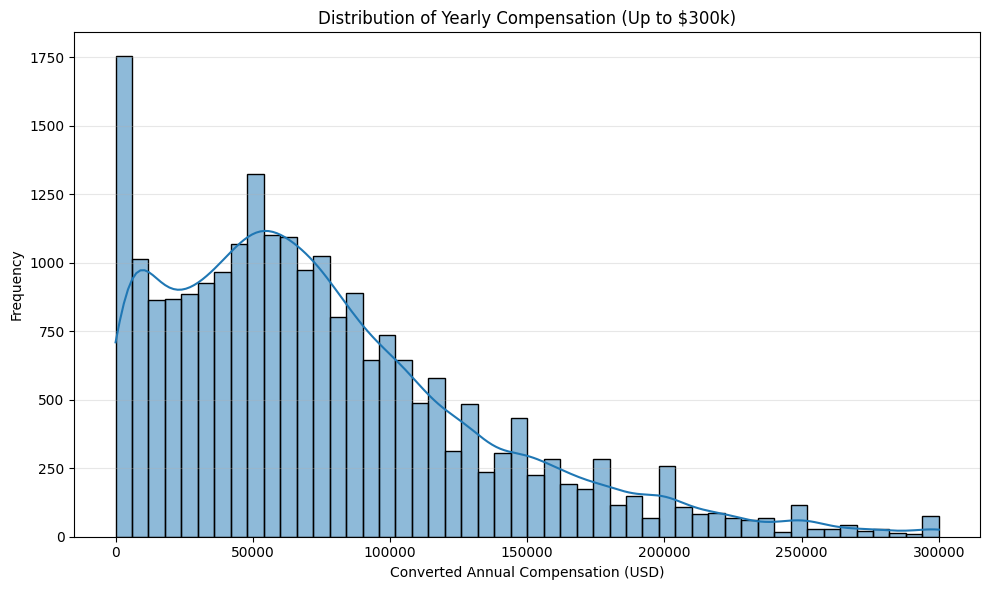

In [4]:
## Write your code here
%pip install seaborn
import seaborn as sns

df_hist = df.dropna(subset=['ConvertedCompYearly'])

#  Create the Line Chart
plt.figure(figsize=(10, 6))
filtered_data = df_hist[df_hist['ConvertedCompYearly'] <= 300000]

sns.histplot(filtered_data['ConvertedCompYearly'], bins=50, kde=True)

# Adding titles and labels
plt.title('Distribution of Yearly Compensation (Up to $300k)')
plt.xlabel('Converted Annual Compensation (USD)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



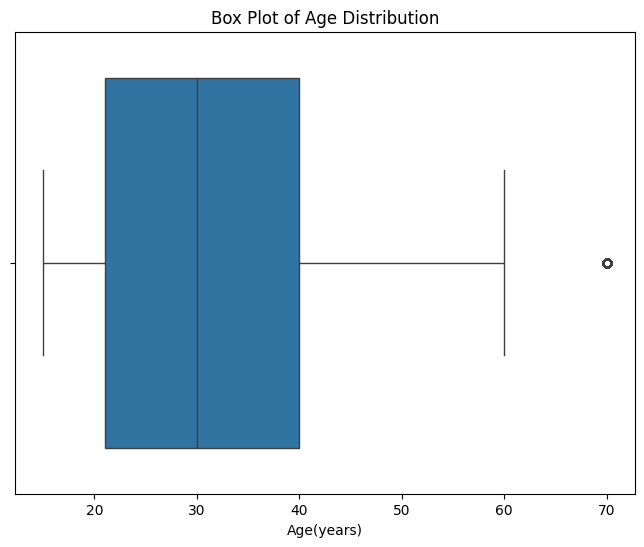

In [5]:
## Write your code here
df_age = df.dropna(subset=['Age'])

age_map = {
    'Under 18 years old': 15, '18-24 years old': 21, '25-34 years old': 30,
    '35-44 years old': 40, '45-54 years old': 50, '55-64 years old': 60,
    '65 years or older': 70
}

# Apply mappings
df_age['Age_Numeric'] = df_age['Age'].map(age_map)

plt.figure(figsize=(8, 6))
sns.boxplot(x=df_age['Age_Numeric'])

# 4. Add titles and labels
plt.title('Box Plot of Age Distribution')
plt.xlabel('Age(years)')

# Display the plot
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



<Axes: title={'center': 'Rlshp between Age and Compensation'}, xlabel='Age_Numeric', ylabel='Converted Yearly Compensation'>

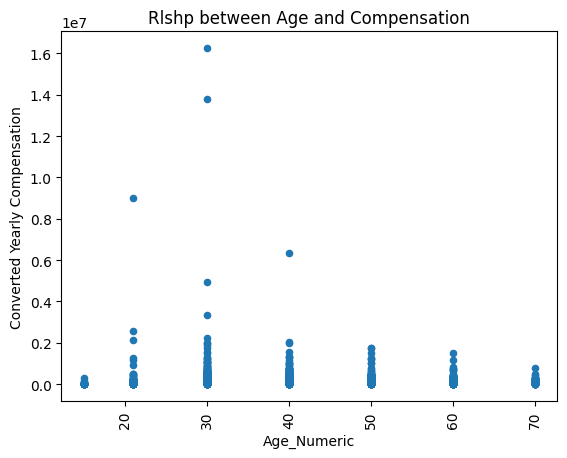

In [6]:
## Write your code here
df_scatter = df.dropna(subset=['Age','ConvertedCompYearly'])

age_map = {
    'Under 18 years old': 15, '18-24 years old': 21, '25-34 years old': 30,
    '35-44 years old': 40, '45-54 years old': 50, '55-64 years old': 60,
    '65 years or older': 70
}

# Apply mappings
df_scatter['Age_Numeric'] = df_scatter['Age'].map(age_map)

df_scatter.plot(
    kind="scatter",
    x="Age_Numeric",
    y="ConvertedCompYearly",
    ylabel="Converted Yearly Compensation",
    title="Rlshp between Age and Compensation",
    rot=90
)


##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


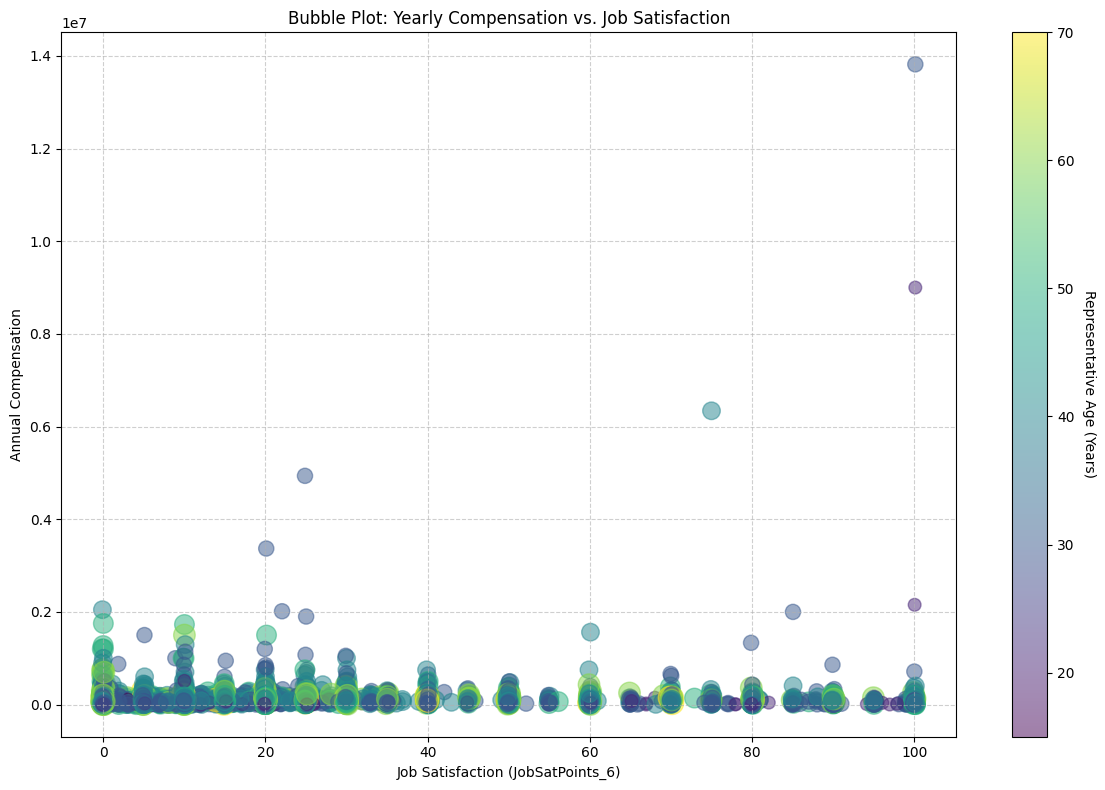

In [7]:
## Write your code here
import numpy as np
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Age'])

#Numeric representatives for each range
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df_clean['Age_Numeric'] = df_clean['Age'].map(age_map)

# Create the Bubble Plot
plt.figure(figsize=(12, 8))

# Adding a small amount of jitter to JobSatPoints_6 helps visualize density
# since satisfaction scores are usually discrete integers
x_jittered = df_clean['JobSatPoints_6'] + np.random.uniform(-0.15, 0.15, size=len(df_clean))

scatter = plt.scatter(
    x=x_jittered, 
    y=df_clean['ConvertedCompYearly'],
    s=df_clean['Age_Numeric'] * 4,  # Adjust size multiplier for visibility
    alpha=0.5,
    c=df_clean['Age_Numeric'],     # Color points by age as well
)

# Formatting and Labels
plt.title('Bubble Plot: Yearly Compensation vs. Job Satisfaction')
plt.xlabel('Job Satisfaction (JobSatPoints_6)')
plt.ylabel('Annual Compensation')

# Colorbar to indicate what colors correspond to which ages
cbar = plt.colorbar(scatter)
cbar.set_label('Representative Age (Years)', rotation=270, labelpad=15)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



/tmp/ipykernel_301/473016686.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


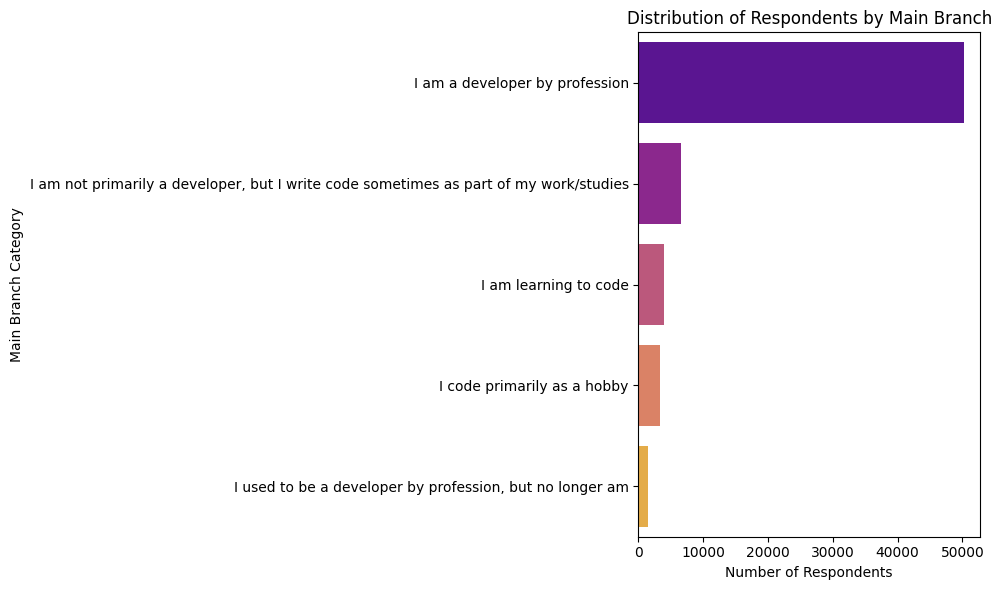

In [8]:
## Write your code here
df_mainbranch = df['MainBranch'].dropna().value_counts().reset_index()
df_mainbranch.columns = ['MainBranch', 'Count']

plt.figure(figsize=(10, 6))

# Map MainBranch to the y-axis to make it horizontal
sns.barplot(
    data=df_mainbranch, 
    x='Count', 
    y='MainBranch', 
    palette='plasma'
)

# titles and labels
plt.title('Distribution of Respondents by Main Branch')
plt.xlabel('Number of Respondents')
plt.ylabel('Main Branch Category')

plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



/tmp/ipykernel_301/1723550315.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


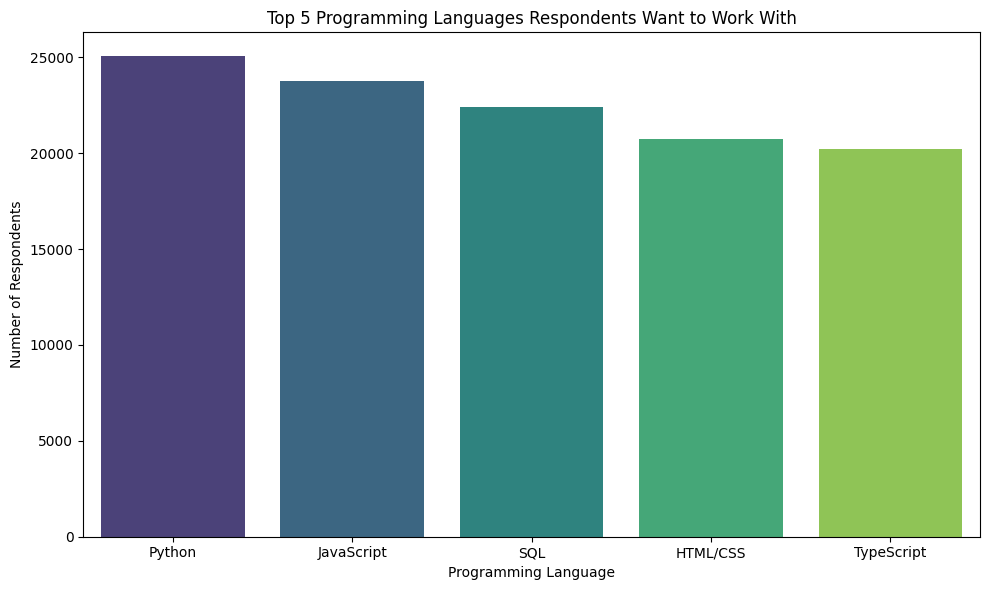

In [9]:
## Write your code 
df_clean = df.dropna(subset=['LanguageWantToWorkWith'])

df_counts = df_clean['LanguageWantToWorkWith'].str.split(';').explode().value_counts()

top_5_lang = df_counts.head(5).reset_index()
top_5_lang.columns = ['Language', 'Count']

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_5_lang, 
    x='Language', 
    y='Count', 
    palette='viridis'
)

plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


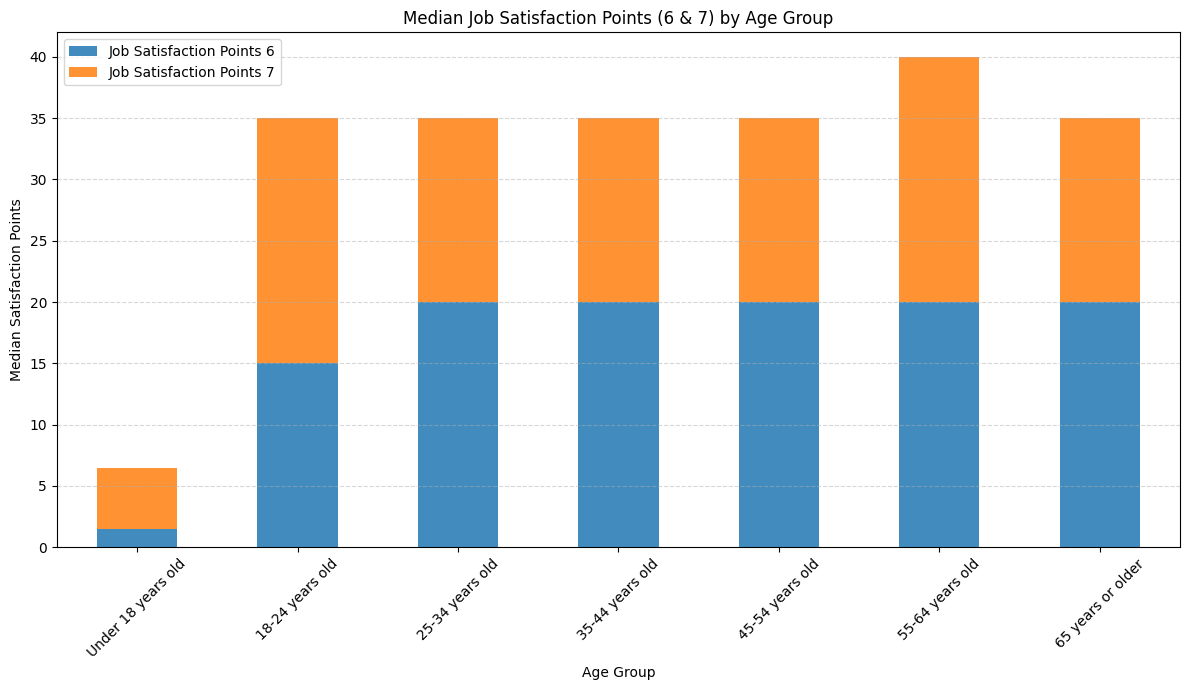

In [10]:
## Write your code here

df_clean = df.dropna(subset=['Age', 'JobSatPoints_6', 'JobSatPoints_7'])

# Calculate Medians by Age Group
median_data = df_clean.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()

age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]
# Reindex the dataframe to match the logical age order
median_data = median_data.reindex(age_order).dropna()

# Create the Stacked Bar Chart
median_data.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7), 
    alpha=0.85
)

# Formatting
plt.title('Median Job Satisfaction Points (6 & 7) by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Satisfaction Points')
plt.xticks(rotation=45)
plt.legend(['Job Satisfaction Points 6', 'Job Satisfaction Points 7'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



/tmp/ipykernel_301/3671081010.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


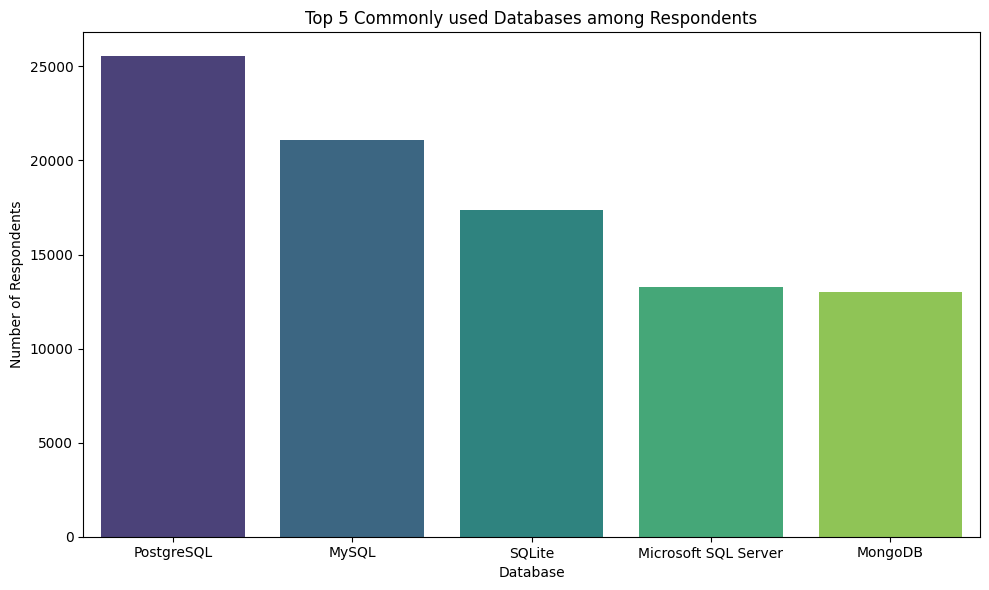

In [11]:
## Write your code here

df_clean = df.dropna(subset=['DatabaseHaveWorkedWith'])

df_counts = df_clean['DatabaseHaveWorkedWith'].str.split(';').explode().value_counts()

top_5_lang = df_counts.head(5).reset_index()
top_5_lang.columns = ['Database', 'Count']

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_5_lang, 
    x='Database', 
    y='Count', 
    palette='viridis'
)

plt.title('Top 5 Commonly used Databases among Respondents')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



/tmp/ipykernel_301/2540998125.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


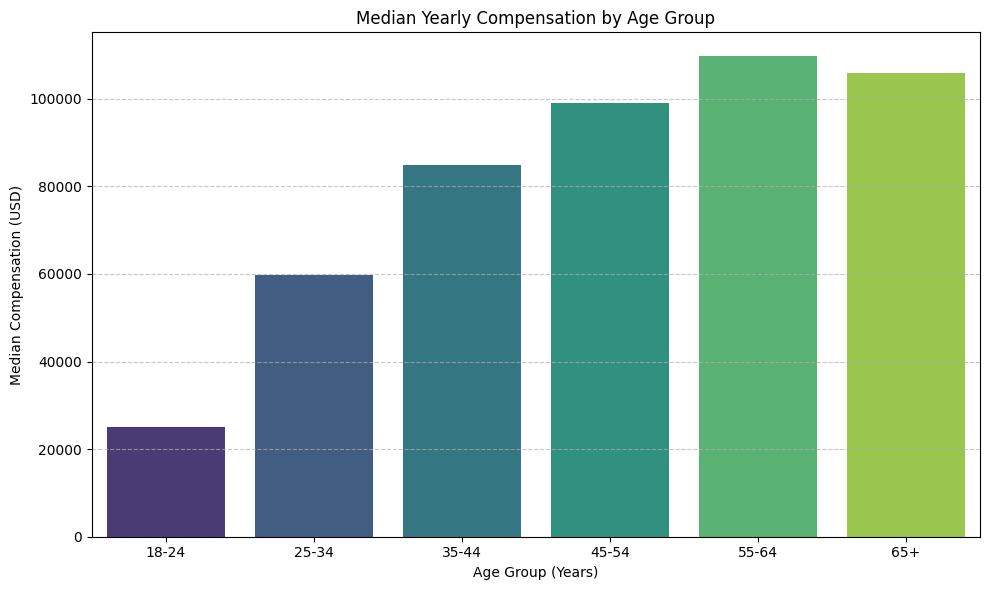

In [14]:

age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_Numeric'] = df['Age'].map(age_map)

df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

df_clean = df.dropna(subset=['Age_Numeric', 'ConvertedCompYearly'])

# Defining the numeric edges for each group
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_clean['AgeGroup'] = pd.cut(df_clean['Age_Numeric'], bins=bins, labels=labels)

# Calculate Median Compensation for each Group
median_data = df_clean.groupby('AgeGroup')['ConvertedCompYearly'].median().reset_index()

# Create the Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data= median_data, 
    x='AgeGroup', 
    y='ConvertedCompYearly', 
    palette='viridis'
)

#  Add Labels and Formatting
plt.title('Median Yearly Compensation by Age Group')
plt.xlabel('Age Group (Years)')
plt.ylabel('Median Compensation (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



/tmp/ipykernel_301/1771240265.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


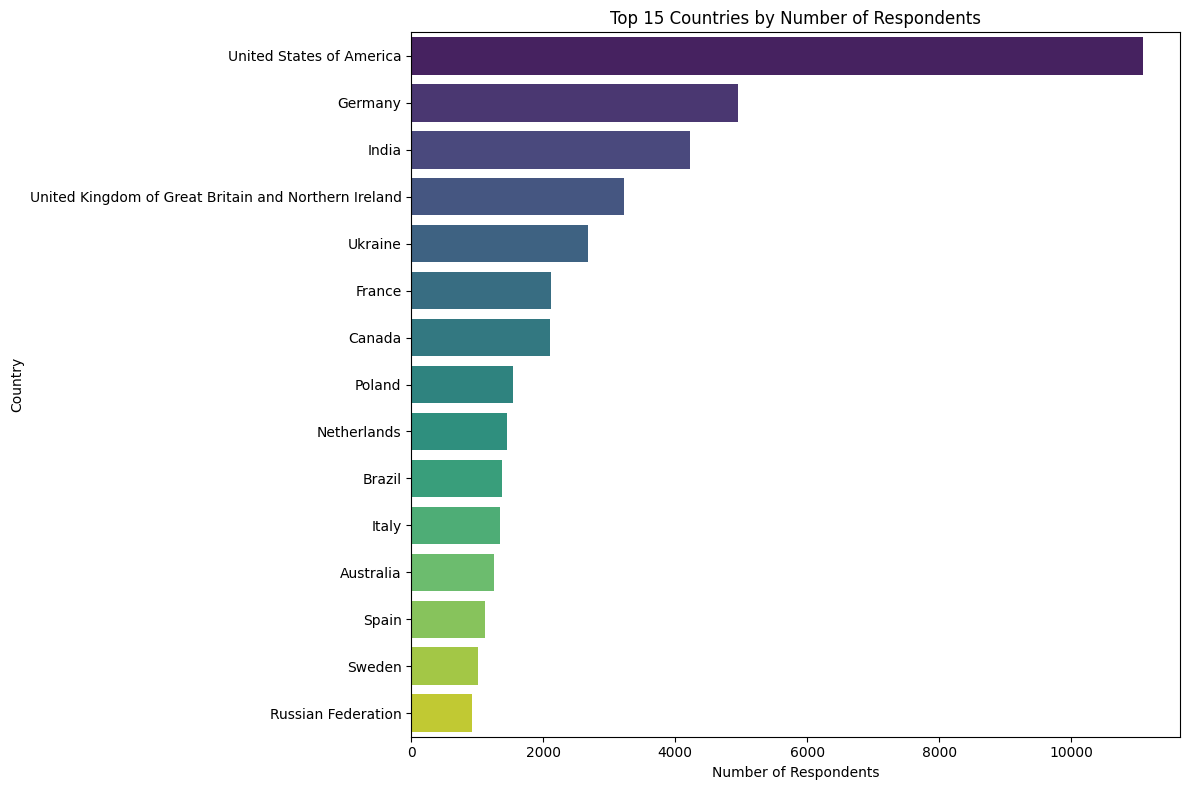

In [12]:
## Write your code here
df_clean = df.dropna(subset=['Country'])
country_counts = df_clean['Country'].value_counts().head(15).reset_index()
country_counts.columns = ['Country', 'RespondentCount']

# 3. Create the Bar Chart
plt.figure(figsize=(12, 8))

sns.barplot(
    data=country_counts, 
    x='RespondentCount', 
    y='Country', 
    palette='viridis'
)


plt.title('Top 15 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
